# Core Module: Robust Denoising Autoencoder
## IMAGINE Pipeline Development

As discussed, simply connecting pre-trained HuggingFace APIs is not enough. The academic and technical core of this project is training a highly robust **Denoising U-Net Autoencoder** to clean up human sketches.

This notebook is dedicated entirely to this phase. It implements:
1. **Infinite Data Generation Pipeline:** Instead of a tiny paired dataset, we use PyTorch to dynamically download the **STL-10** (100,000 images) dataset. We extract the edges (Clean Target) and synthetically inject chaotic noise and strokes (Rough Input). This trains the model to understand infinite structural shapes.
2. **Advanced U-Net Architecture:** Upgraded with Residual connections, InstanceNormalization, and Dropout for robust feature extraction.
3. **Combined Loss Function:** Uses a mix of BCE (Binary Cross Entropy) and L1 Loss for mathematically sharp line reconstructions.
4. **Production Training Engine:** Tracks metrics and saves the best model checkpoint.

In [1]:
# 1. Setup & Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Device for Training: {DEVICE}")

Target Device for Training: cuda


### 2. The Powerful Data Synthesis Engine
This is the secret behind papers like "Learning to Simplify". We take normal photos, extract the "Clean Sketch" using Edge Detection, and then digitally damage it with noise and messy strokes to create the "Rough Sketch". The Autoencoder learns to map Rough -> Clean perfectly.

### **STUDENT EXERCISE 1: Edge Detection**
Use OpenCV's Canny edge detector to extract the lines from the `gray` image. Use thresholds 100 and 200.


In [2]:
IMG_SIZE = 128 # 128x128 resolution for balanced training speed and structural complexity

def generate_sketch_pair(image_tensor):
    """
    Takes a standard PyTorch BGR/RGB Image Tensor [C, H, W]
    Returns: rough_tensor [1, H, W], clean_tensor [1, H, W]
    """
    # Convert to Numpy for OpenCV Processing
    img_np = (image_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    if img_np.shape[2] == 3:
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = img_np.squeeze()
        
    # --- 1. Get Clean Target Sketch (Canny Edge Detection + Inversion) ---
    # Canny gives white lines on black background. We invert so it's black lines on white background.
    edges = cv2.Canny(gray, 50, 150)  # Apply Canny edge detection
    clean_sketch = 255 - edges 
    
    # --- 2. Generate Rough Sketch (Synthetic Degradation) ---
    rough_sketch = clean_sketch.copy()
    h, w = rough_sketch.shape
    
    # A. Add Gaussian Background smudging (pencil dust)
    noise = np.random.normal(200, 35, (h, w)).astype(np.uint8)
    rough_sketch = cv2.addWeighted(rough_sketch, 0.6, noise, 0.4, 0)
    
    # B. Add random structural "messy strokes" to mimic human double-drawing lines
    num_strokes = random.randint(15, 40)
    for _ in range(num_strokes):
        x1, y1 = random.randint(0, w), random.randint(0, h)
        x2 = x1 + random.randint(-40, 40)
        y2 = y1 + random.randint(-40, 40)
        thickness = random.randint(1, 2)
        color = random.randint(50, 180) # Gray/Black strokes
        cv2.line(rough_sketch, (x1, y1), (x2, y2), color, thickness)
        
    # C. Dilate slightly to make the sketch look thicker and smudged
    kernel = np.ones((2, 2), np.uint8)
    rough_sketch = cv2.erode(rough_sketch, kernel, iterations=1) # Erode darkens the lines
    
    # Convert back to Tensors (Normalize to 0-1)
    rough_tensor = torch.from_numpy(rough_sketch).float().unsqueeze(0) / 255.0
    clean_tensor = torch.from_numpy(clean_sketch).float().unsqueeze(0) / 255.0
    
    return rough_tensor, clean_tensor

class SyntheticSketchDataset(Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
        
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img_tensor, _ = self.base_dataset[idx] # Ignore labels
        rough, clean = generate_sketch_pair(img_tensor)
        return rough, clean

# Let's use STL10 "unlabeled" split. It has 100,000 images, giving us a massively diverse array of structures to clean!
print("Downloading/Loading STL10 Dataset (100k images)...")
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])
base_data = torchvision.datasets.STL10(root='./data', split='unlabeled', download=True, transform=transform)

# Split 90k for training, 10k for validation
train_size = 90000
val_size = len(base_data) - train_size
train_base, val_base = torch.utils.data.random_split(base_data, [train_size, val_size])

train_dataset = SyntheticSketchDataset(train_base)
val_dataset = SyntheticSketchDataset(val_base)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
print("Dataset Ready!")

Downloading/Loading STL10 Dataset (100k images)...


100%|██████████| 2.64G/2.64G [01:07<00:00, 39.1MB/s]


Dataset Ready!


Let's visualize exactly what the Autoencoder will learn to fix.

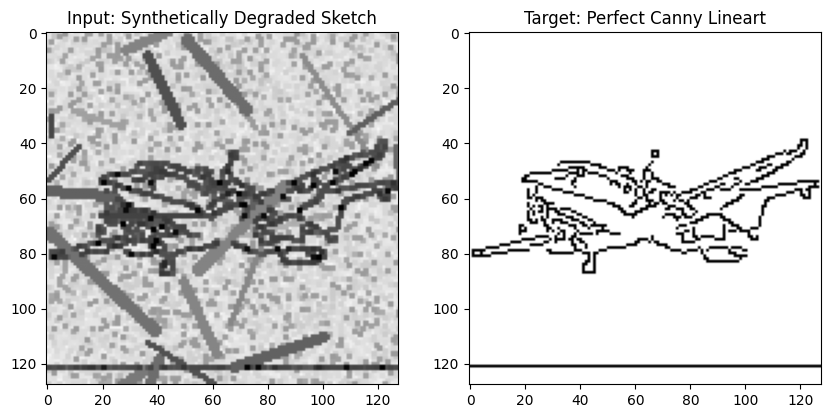

In [3]:
temp_rough, temp_clean = train_dataset[random.randint(0, 1000)]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(temp_rough.squeeze(), cmap='gray')
ax[0].set_title("Input: Synthetically Degraded Sketch")
ax[1].imshow(temp_clean.squeeze(), cmap='gray')
ax[1].set_title("Target: Perfect Canny Lineart")
plt.show()

### 3. Advanced Residual U-Net Architecture
Standard U-Nets suffer from vanishing gradients. Adding Residual connections (`x + conv(x)`) makes the network incredibly stable and robust.

### **STUDENT EXERCISE 2: Model Architecture**
Define the core convolutional layers for the U-Net. Remember that `padding=1` with a `kernel_size=3` keeps the spatial dimensions identical!


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)  # Fill in kernel & padding
        self.bn1 = nn.InstanceNorm2d(out_channels) # InstanceNorm is better for generative tasks
        self.relu = nn.LeakyReLU(0.2, inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.InstanceNorm2d(out_channels)
        
        # Skip connection matcher
        self.match = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        skip = self.match(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + skip) # Residual addition

class RobustUNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder
        self.enc1 = ResidualBlock(1, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout2d(0.2)
        
        # Bottleneck
        self.bottleneck = ResidualBlock(256, 512)
        
        # Decoder
        self.up3 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)  # Up from 512 to 256
        self.dec3 = ResidualBlock(512, 256) # 512 because 256(up) + 256(skip)
        
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ResidualBlock(256, 128)
        
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ResidualBlock(128, 64)
        
        self.final = nn.Conv2d(64, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encode
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        
        # Bridge
        b = self.bottleneck(self.pool(self.dropout(e3)))
        
        # Decode
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(self.dropout(d3))
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.sigmoid(self.final(d1))

model = RobustUNet().to(DEVICE)
print("Architecture initialized.")

Architecture initialized.


### 4. Robust Training Engine
This engine calculates both L1 Loss (predicts absolute structural differences) and BCE Loss (excellent for black/white pixel mapping). It saves the best checkpoint automatically.

### **STUDENT EXERCISE 3: The Training Loop**
Here is the core of Deep Learning! You need to:
1. Define the Loss functions (L1 and BCE).
2. Pass the model parameters to the Optimizer.
3. Complete the backpropagation step (Zero grad -> Backward -> Step).


In [5]:
EPOCHS = 10
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)  # Pass model parameters to the optimizer
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

l1_loss = nn.L1Loss()  # Initialize L1Loss
bce_loss = nn.BCELoss()  # Initialize Binary Cross Entropy Loss

def combined_loss(pred, target):
    return 0.2 * l1_loss(pred, target) + 0.8 * bce_loss(pred, target)

best_val_loss = float('inf')
os.makedirs('checkpoints', exist_ok=True)

print("Launching Training Engine...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    for batch_idx, (rough, clean) in enumerate(train_loader):
        rough, clean = rough.to(DEVICE), clean.to(DEVICE)
        
        optimizer.zero_grad()  # Zero out the gradients
        pred = model(rough)
        
        loss = combined_loss(pred, clean)
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model weights
        
        train_loss += loss.item()
        
        # Print progress sparingly (Colab output limit)
        if batch_idx % 200 == 0:
            print(f"Epoch [{(epoch+1)}/{EPOCHS}] Batch [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")
            
    # Validation Step
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for rough, clean in val_loader:
            rough, clean = rough.to(DEVICE), clean.to(DEVICE)
            pred = model(rough)
            val_loss += combined_loss(pred, clean).item()
            
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    print(f"Epoch {epoch+1} Completed | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "checkpoints/robust_autoencoder_best.pth")
        print(f"Saved New Best Model! Checkpoint updated.")
        
print("\nTraining Complete! The robust autoencoder_weights.pth is ready for the main pipeline!")

Launching Training Engine...
Epoch [1/10] Batch [0/2812] Loss: 0.6490
Epoch [1/10] Batch [200/2812] Loss: 0.1205
Epoch [1/10] Batch [400/2812] Loss: 0.1014
Epoch [1/10] Batch [600/2812] Loss: 0.0872
Epoch [1/10] Batch [800/2812] Loss: 0.0764
Epoch [1/10] Batch [1000/2812] Loss: 0.0859
Epoch [1/10] Batch [1200/2812] Loss: 0.0969
Epoch [1/10] Batch [1400/2812] Loss: 0.0692
Epoch [1/10] Batch [1600/2812] Loss: 0.0785
Epoch [1/10] Batch [1800/2812] Loss: 0.0660
Epoch [1/10] Batch [2000/2812] Loss: 0.0787
Epoch [1/10] Batch [2200/2812] Loss: 0.0623
Epoch [1/10] Batch [2400/2812] Loss: 0.0826
Epoch [1/10] Batch [2600/2812] Loss: 0.0721
Epoch [1/10] Batch [2800/2812] Loss: 0.0784
Epoch 1 Completed | Train Loss: 0.0876 | Val Loss: 0.0737
Saved New Best Model! Checkpoint updated.
Epoch [2/10] Batch [0/2812] Loss: 0.0639
Epoch [2/10] Batch [200/2812] Loss: 0.0804
Epoch [2/10] Batch [400/2812] Loss: 0.0617
Epoch [2/10] Batch [600/2812] Loss: 0.0727
Epoch [2/10] Batch [800/2812] Loss: 0.0748
Epoch

### 5. Final Visual Verification

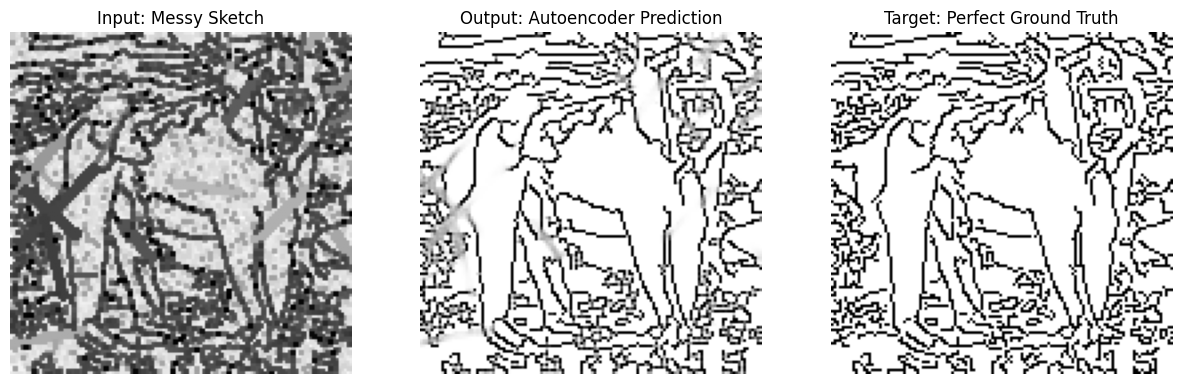

In [6]:
model.load_state_dict(torch.load("checkpoints/robust_autoencoder_best.pth"))
model.eval()

with torch.no_grad():
    r, c = next(iter(val_loader))
    r, c = r.to(DEVICE), c.to(DEVICE)
    p = model(r)
    
    idx = 0
    rough_np = r[idx].cpu().squeeze().numpy()
    clean_np = c[idx].cpu().squeeze().numpy()
    pred_np = p[idx].cpu().squeeze().numpy()
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 6))
    ax[0].imshow(rough_np, cmap='gray')
    ax[0].set_title("Input: Messy Sketch")
    ax[0].axis('off')
    
    ax[1].imshow(pred_np, cmap='gray')
    ax[1].set_title("Output: Autoencoder Prediction")
    ax[1].axis('off')
    
    ax[2].imshow(clean_np, cmap='gray')
    ax[2].set_title("Target: Perfect Ground Truth")
    ax[2].axis('off')
    
    plt.show()